C:\Users\cynth\AppData\Local\Temp\ipykernel_12904\4179193430.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trans_metrics = df.groupby(['subject_id', 'recording_id']).apply(analyze_transitions).reset_index()
C:\Users\cynth\AppData\Local\Temp\ipykernel_12904\4179193430.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_base = df.groupby(['subject_id', 'recording_id']).apply(calculate_metrics).reset_ind

    subject_id     SE_pct     N3_pct  num_transitions  num_awakenings
0            0  80.787342  32.576261            115.5            16.5
1            7  77.733188  22.324594            113.5             6.0
2            9  87.117619  14.199846            100.0             6.0
3           13  85.004869  16.838488            102.0            18.0
4           14  81.264094  18.644498             82.5            17.5
5           15  68.124739  20.665526             66.5             7.0
6           16  81.712690  16.657076            104.0            10.5
7           17  71.845649  21.686115            152.0            16.5
8           27  81.862348  19.484740            130.5            17.0
9           28  81.979390  16.883602             71.5            14.5
10          31  69.828094  19.120120            168.0            37.0
11          45  80.743588  30.039486            170.0            37.0
12          59  56.092188  14.981155            224.5            54.5
13          65  50.6

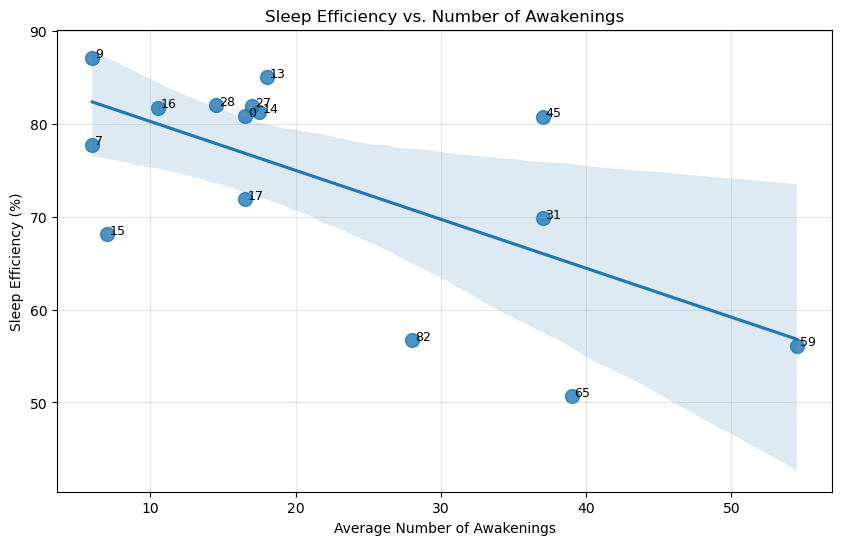

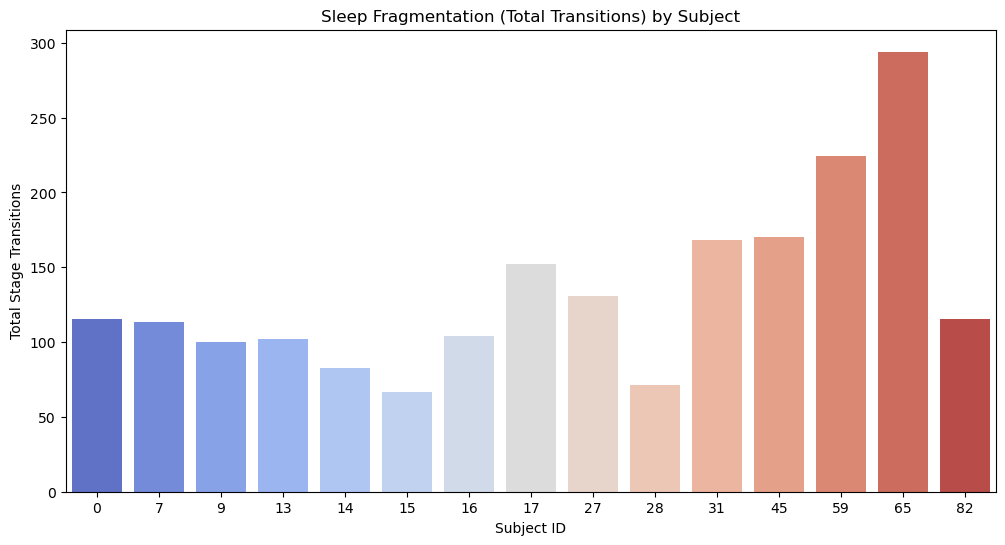

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../datasets/sleepedf_15_stratified_cropped.csv')

# Sort by recording and epoch to ensure temporal order
df = df.sort_values(['recording_id', 'epoch'])

# Calculate transitions
def analyze_transitions(group):
    # Shift sleep stage to find changes
    group['prev_stage'] = group['sleep_stage'].shift(1)
    
    # Identify transition points
    transitions = group[group['sleep_stage'] != group['prev_stage']]
    num_transitions = len(transitions) - 1 if len(transitions) > 0 else 0
    
    # Awakenings (transition from sleep to W)
    # Define sleep stages
    sleep_stages = ['N1', 'N2', 'N3', 'REM']
    awakenings = group[(group['prev_stage'].isin(sleep_stages)) & (group['sleep_stage'] == 'W')]
    num_awakenings = len(awakenings)
    
    return pd.Series({
        'num_transitions': num_transitions,
        'num_awakenings': num_awakenings
    })

# Apply to each recording
trans_metrics = df.groupby(['subject_id', 'recording_id']).apply(analyze_transitions).reset_index()

# Aggregate to subject level (average across recordings)
subject_trans = trans_metrics.groupby('subject_id').mean(numeric_only=True).reset_index()

# Merge with previous summary metrics for correlation analysis
# (Re-calculating previous metrics for context)
def calculate_metrics(group):
    total = len(group)
    counts = group['sleep_stage'].value_counts()
    tst = counts.get('N1', 0) + counts.get('N2', 0) + counts.get('N3', 0) + counts.get('REM', 0)
    se = (tst / total) * 100 if total > 0 else 0
    n3_pct = (counts.get('N3', 0) / tst * 100) if tst > 0 else 0
    return pd.Series({'SE_pct': se, 'N3_pct': n3_pct})

subject_base = df.groupby(['subject_id', 'recording_id']).apply(calculate_metrics).reset_index()
subject_base = subject_base.groupby('subject_id').mean(numeric_only=True).reset_index()

# Combined DataFrame
final_summary = pd.merge(subject_base, subject_trans, on='subject_id')

# Correlation Plot: Sleep Efficiency vs. Number of Awakenings
plt.figure(figsize=(10, 6))
sns.regplot(data=final_summary, x='num_awakenings', y='SE_pct', scatter_kws={'s':100})
for i in range(final_summary.shape[0]):
    plt.text(final_summary.num_awakenings[i]+0.2, final_summary.SE_pct[i], 
             int(final_summary.subject_id[i]), fontsize=9)
plt.title('Sleep Efficiency vs. Number of Awakenings')
plt.xlabel('Average Number of Awakenings')
plt.ylabel('Sleep Efficiency (%)')
plt.grid(True, alpha=0.3)
plt.savefig('efficiency_vs_awakenings.png')

# Fragmentation Analysis Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=final_summary.sort_values('num_transitions'), x='subject_id', y='num_transitions', palette='coolwarm')
plt.title('Sleep Fragmentation (Total Transitions) by Subject')
plt.ylabel('Total Stage Transitions')
plt.xlabel('Subject ID')
plt.savefig('sleep_fragmentation.png')

print(final_summary)
final_summary.to_csv('subject_fragmentation_analysis.csv', index=False)